# Подготовка данных и окружения

In [2]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import torch.nn as nn
import torch.optim as optim

### Вывод изображений

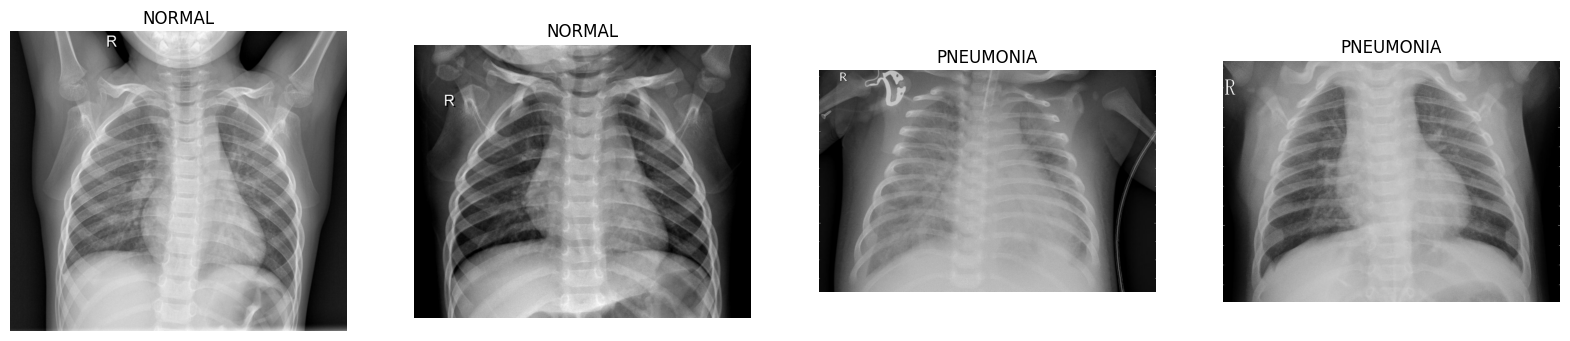

In [8]:
def show_sample_images(root_dir):
    normal_dir = os.path.join(root_dir, 'train', 'NORMAL')
    pneumonia_dir = os.path.join(root_dir, 'train', 'PNEUMONIA')
    normal_files = os.listdir(normal_dir)[:2]
    pneumonia_files = os.listdir(pneumonia_dir)[:2]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    images_to_show = []
    for f in normal_files:
        images_to_show.append((os.path.join(normal_dir, f), "NORMAL"))
    for f in pneumonia_files:
        images_to_show.append((os.path.join(pneumonia_dir, f), "PNEUMONIA"))
    for i, (path, title) in enumerate(images_to_show):
        img = Image.open(path).convert('RGB') 
        axes[i].imshow(img, cmap='gray')      
        axes[i].set_title(title)
        axes[i].axis('off')                 
    plt.show()


data_path = '../datasets/chest_xray'
show_sample_images(data_path)

### Подготовка данных к работе с ИИ

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        # --- АУГМЕНТАЦИИ  ДЛЯ 4 БОНУСНОГО ЗАДАНИЯ ---
        transforms.RandomHorizontalFlip(p=0.5), # С вероятностью 50% зеркалим картинку
        transforms.RandomRotation(degrees=10),  # Поворачиваем на +/- 10 градусов
        transforms.ColorJitter(brightness=0.1, contrast=0.1), # Чуть меняем свет и контраст
        # ------------------------------------------
        transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]),
}


train_dataset = datasets.ImageFolder(os.path.join(data_path, 'train'), data_transforms['train'])
test_dataset = datasets.ImageFolder(os.path.join(data_path, 'test'), data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Аугментация включена.")

print("Данные успешно подготовлены!")
print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

Аугментация включена.
Данные успешно подготовлены!
Размер обучающей выборки: 5216
Размер тестовой выборки: 624


# Создание и обучение нейронной сети

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PyramidCNN(nn.Module):
    def __init__(self):
        super(PyramidCNN, self).__init__()
        
        # Блок 1 (32 фильтра)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2) # -> 112x112

        # Блок 2 (64 фильтра)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2) # -> 56x56
        
        # Блок 3 (128 фильтров)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2) # -> 28x28
        
        # Блок 4 (256 фильтров) 
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2) # -> 14x14

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(256 * 14 * 14, 512) 
        self.relu5 = nn.ReLU()
        self.dropout = nn.Dropout(0.5) 
        self.fc2 = nn.Linear(512, 1) 

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu5(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = PyramidCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Модель создана")

Модель создана


In [11]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Оценка качества модели

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 15  

print("Запуск обучения")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
        probs = torch.sigmoid(logits) 
        predicted = (probs > 0.5).float()
        
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    print(f"Epoch {epoch+1}/{num_epochs} -> Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
print("Модель обучена")

Запуск обучения
Epoch 1/15 -> Loss: 0.2411, Accuracy: 0.9109
Epoch 2/15 -> Loss: 0.1298, Accuracy: 0.9469
Epoch 3/15 -> Loss: 0.1074, Accuracy: 0.9594
Epoch 4/15 -> Loss: 0.1015, Accuracy: 0.9617
Epoch 5/15 -> Loss: 0.0889, Accuracy: 0.9663
Epoch 6/15 -> Loss: 0.0810, Accuracy: 0.9697
Epoch 7/15 -> Loss: 0.0794, Accuracy: 0.9718
Epoch 8/15 -> Loss: 0.0875, Accuracy: 0.9668
Epoch 9/15 -> Loss: 0.0791, Accuracy: 0.9703
Epoch 10/15 -> Loss: 0.0789, Accuracy: 0.9728
Epoch 11/15 -> Loss: 0.0680, Accuracy: 0.9749
Epoch 12/15 -> Loss: 0.0626, Accuracy: 0.9760
Epoch 13/15 -> Loss: 0.0580, Accuracy: 0.9780
Epoch 14/15 -> Loss: 0.0573, Accuracy: 0.9776
Epoch 15/15 -> Loss: 0.0591, Accuracy: 0.9778
Модель обучена


In [17]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

print("Начинаем тестирование...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(inputs)
        
        loss = criterion(logits, labels)
        test_loss += loss.item() * inputs.size(0)
        
        probs = torch.sigmoid(logits) 
        predicted = (probs > 0.5).float()
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_loss = test_loss / total
accuracy = correct / total

print(f"\nРЕЗУЛЬТАТ НА ТЕСТОВЫХ ДАННЫХ:")
print(f"Loss: {avg_loss:.4f}")
print(f"Accuracy: {accuracy:.4%}")

if accuracy > 0.80:
    print("Отличный результат!")
elif accuracy > 0.70:
    print("Задание выполнено.")
else:
    print("Модель не готова.")

Начинаем тестирование...

РЕЗУЛЬТАТ НА ТЕСТОВЫХ ДАННЫХ:
Loss: 0.9513
Accuracy: 77.0833%
Задание выполнено.


# Аугментация данных

После добавление аугментации данных, точной сверточной нейросети повысилась с 71% до 77.1%. Модель стала чувствительнее с признакам, умнее и точнее! Качество обучения повысилась и модель стала лучше распознавать признаки пневмании на различных снимках.